Script for plotting evolution of system indicators for single replication of the experiment

In [1]:
### INPUT ###
repl_id = 0
scenario_name = 'sp-repl_id-{}'.format(repl_id)
dem_mgmt_schemes = ['tmc100', 'tmc20', 'tmc15', 'tmc10', 'tmc5', 'tmc3']
# dem_mgmt_schemes = ['tmc10']
dem_mgmt_labels = ['TMC100', 'TMC20', 'TMC15', 'TMC10', 'TMC5', 'TMC3']
# dem_mgmt_labels = ['TMC10']
mode_labels = ["Car", "RH - solo", "RH - pool", "PT", "Bike"]
unhindered_travel_scn = 'tmc100'

In [2]:
import os
import json
import pandas as pd
import matplotlib.pyplot as plt
from eval_utils import *
import matplotlib.ticker as mtick
import numpy as np
import glob
import re

In [3]:
## Initialise evaluation ##

# Set paths
path = os.getcwd()
result_path = os.path.join(path,'..','..','..','results')
if not os.path.exists(os.path.join(path, 'plots', str(repl_id))):
    os.mkdir(os.path.join(path, 'plots', str(repl_id)))

# Initialise dictionaries that will contain different demand management schemes
params = {}
evo_df = {}

In [4]:
# Load different demand management schemes
for scheme in dem_mgmt_schemes:
    # Result path for demand management scenario
    scheme_path = os.path.join(result_path, '{}-{}'.format(scheme, scenario_name))
    if os.path.exists(scheme_path):
        # Load params
        with open(os.path.join(scheme_path,'0_params.json')) as f:
            params[scheme] = json.load(f)
        # Load relevant csv's: market shares and credit market indicators
        market_shares = load_market_indicators(scheme_path)
        market_shares.index.name = 'day'
        evo_df[scheme] = market_shares.copy().drop(['ptcp_dem_mh','ptcp_sup_mh','ptcp_sup_sh_0','ptcp_sup_sh_1'], axis=1)
        # evo_df[scheme] = market_shares[['ptcp_dem_sh_0','ptcp_dem_sh_1','bike','car','pt']].copy()
        evo_df[scheme] = evo_df[scheme].rename(columns={'ptcp_dem_sh_0': 'rh_solo', 'ptcp_dem_sh_1': 'rh_pool', 'paxkm_rs_0': 'paxkm_solo', 'paxkm_rs_1': 'paxkm_pool', 'vkt_rs_0': 'vkt_solo', 'vkt_rs_1': 'vkt_pool'})
        if scheme.startswith('tmc'):
            evo_df[scheme]['not_enough_credit'] = market_shares['not_enough_credit']
            tmc_indicators = load_tmc_indicators(scheme_path)
            tmc_indicators.index.name = 'mc_iter'
            evo_df[scheme] = pd.concat([evo_df[scheme], tmc_indicators], axis=1)
            # evo_df[scheme] = evo_df[scheme].loc[evo_df[scheme].index >= (params[scheme]['nD'] - params[scheme]['tmc']['duration'])]
            evo_df[scheme].reset_index(drop=True, inplace=True)
            evo_df[scheme].index.name = 'mc_iter'
n_days_eql = params[scheme]['convergence']['moving_average_window']+params[scheme]['convergence']['stable_iters']

In [5]:
evo_df['tmc10']

,rh_solo,rh_pool,bike,car,pt,not_enough_credit,paxkm_bike,trips_bike_center,paxkm_car,trips_car_center,...,trips_rs_1_center,vkt_solo,vkt_pool,vkt_repos,vkt_car,total_perc_gtt,i_mode_choice,price,transaction_volume,oversupply
mc_iter,,,,,,,,,,,,,,,,,,,,,
0,5,93,1026,251,51,0,4940.398927,0,1142.198174,0,...,0,23.425935,564.700844,139.424860,1416.743576,1044.299026,0,0.160,11643.790488,7.451590
1,2,92,1028,245,59,0,4955.300873,0,1115.837239,0,...,0,8.291626,554.037664,126.145018,1384.076538,1052.259103,1,0.162,11643.831335,-12.718016
2,13,89,1019,252,53,0,4892.381063,0,1155.907603,0,...,0,70.770330,563.653825,150.802920,1427.618202,1038.907455,2,0.162,11649.968061,-1.585466
3,10,94,1012,244,66,0,4880.993334,0,1102.573017,0,...,0,53.310339,569.448077,146.028718,1353.588209,1051.930045,3,0.162,11646.027107,10.283482
4,8,84,1035,234,65,0,4974.246991,0,1057.521923,0,...,0,52.451689,504.863030,136.182060,1308.419690,1056.260783,4,0.162,11649.807165,2.241853
5,10,94,1022,242,58,0,4906.104266,0,1111.712372,0,...,0,69.153571,579.823822,126.080404,1381.666057,1046.524175,5,0.162,11648.886371,4.308432
6,10,77,1031,253,55,0,4989.691111,0,1146.717381,0,...,0,49.513490,470.930588,138.615318,1409.005994,1053.698005,6,0.162,11647.996925,6.111655


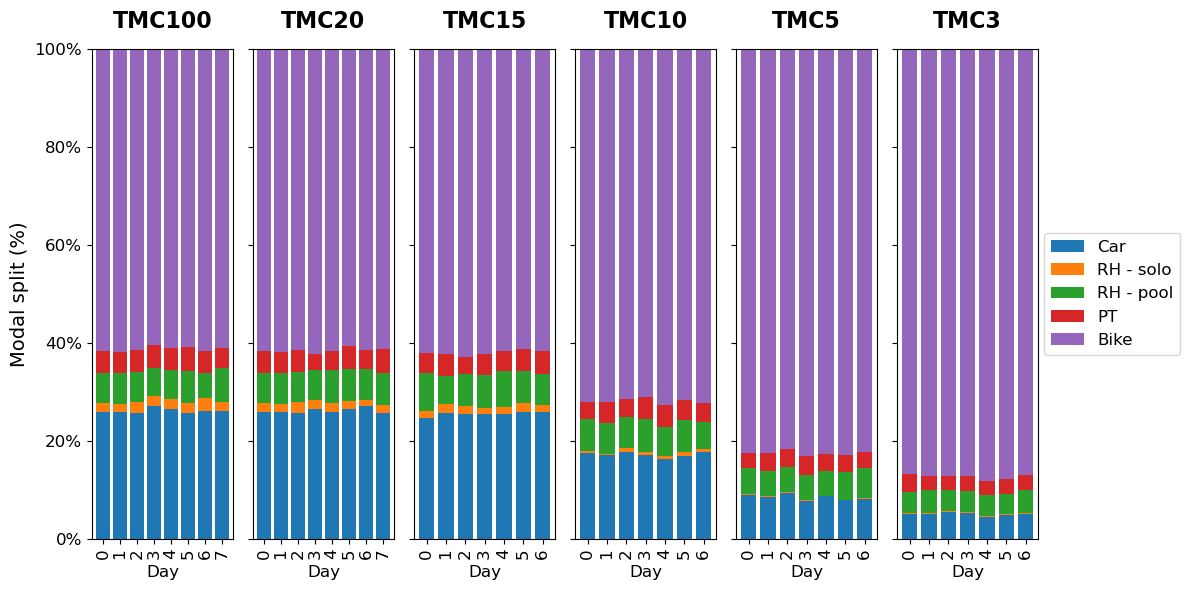

In [6]:
### Plot TMC scenario evolution
n_tmc_scenarios = sum(1 for item in dem_mgmt_schemes if item.startswith("tmc"))
# height_ratios = [2, 1, 1, 1]
fig, axes = plt.subplots(nrows=1, ncols=n_tmc_scenarios, figsize=(12, 6), sharey='row')
i = 0

for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"): 
        # Plot 1: market shares
        evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].div(evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].sum(axis=1), axis=0).mul(100).plot(kind='bar', stacked=True, ax=axes[i], width=0.8)
        axes[i].set_ylabel('Modal split (%)',fontsize=14)
        axes[i].get_legend().remove()
        # axes[i].set_xticks(range(0, params[scheme]['tmc']['duration'], 5))
        # axes[i].set_xticklabels(range(0, params[scheme]['tmc']['duration'], 5),rotation=0)
        axes[i].set_xlabel('Day', fontsize=12)
        axes[i].set_ylim(0,100)
        axes[i].yaxis.set_major_formatter(mtick.PercentFormatter())

        # # Plot 4: mean_balance
        # plot_index = 3
        # evo_df[scheme]['mean_balance'].plot(ax=axes[plot_index, i])
        # axes[plot_index, i].set_ylabel('Avg. credit balance', fontsize=14)
        # axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # # Plot 2: credit_price
        # plot_index = 1
        # evo_df[scheme]['price'].plot(ax=axes[plot_index, i])
        # axes[plot_index, i].set_ylabel('Credit price (€)', fontsize=14)
        # axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # # Plot 3: transaction volume
        # plot_index = 2
        # (evo_df[scheme]['transaction_volume'] / params[scheme]['nP']).plot(ax=axes[plot_index, i])
        # ((abs(evo_df[scheme]['oversupply'])) / params[scheme]['nP']).plot(ax=axes[plot_index, i])
        # axes[plot_index, i].set_ylabel('Avg. buy/sell offer quant.', fontsize=14)
        # axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # Subtitle for scheme
        axes[i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=15, fontsize=16)

        if i == n_tmc_scenarios-1:
            axes[i].legend(labels=mode_labels, bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0, fontsize=12)
            # axes[2, i].legend(labels=['Successful', 'Denied'], bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0, fontsize=12)

        i+=1

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=12)
fig.tight_layout()
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'tmc-evo-modalsplit.png'), facecolor='w')


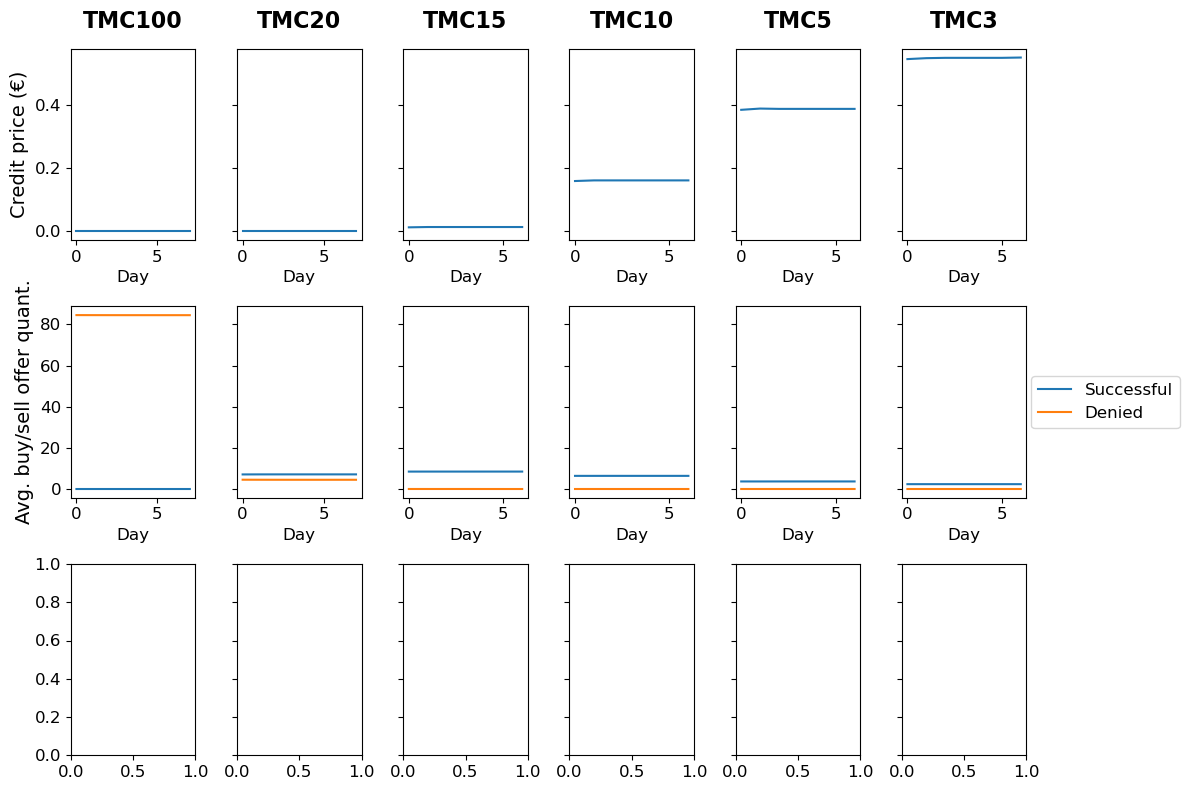

In [7]:
### Plot TMC scenario evolution
n_tmc_scenarios = sum(1 for item in dem_mgmt_schemes if item.startswith("tmc"))
height_ratios = [1, 1, 1]
fig, axes = plt.subplots(nrows=3, ncols=n_tmc_scenarios, figsize=(12, 8), sharey='row', gridspec_kw={'height_ratios': height_ratios})
i = 0

for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"): 
        # Plot 1: market shares
        # evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].div(params[scheme]['nP']).mul(100).plot(kind='bar', stacked=True, ax=axes[0, i], width=0.8)
        # axes[0, i].set_ylabel('Modal split (%)',fontsize=14)
        # axes[0, i].get_legend().remove()
        # axes[0, i].set_xticks(range(0, params[scheme]['tmc']['duration'], 5))
        # axes[0, i].set_xticklabels(range(0, params[scheme]['tmc']['duration'], 5),rotation=0)
        # axes[0, i].set_xlabel('Day', fontsize=12)
        # axes[0, i].set_ylim(0,100)
        # axes[0, i].yaxis.set_major_formatter(mtick.PercentFormatter())

        # Plot 4: mean_balance
        # plot_index = 2
        # evo_df[scheme]['mean_balance'].plot(ax=axes[plot_index, i])
        # axes[plot_index, i].set_ylabel('Avg. credit balance', fontsize=14)
        # axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # Plot 2: credit_price
        plot_index = 0
        evo_df[scheme]['price'].plot(ax=axes[plot_index, i])
        axes[plot_index, i].set_ylabel('Credit price (€)', fontsize=14)
        axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # Plot 3: transaction volume
        plot_index = 1
        (evo_df[scheme]['transaction_volume'] / params[scheme]['nP']).plot(ax=axes[plot_index, i])
        ((abs(evo_df[scheme]['oversupply'])) / params[scheme]['nP']).plot(ax=axes[plot_index, i])
        axes[plot_index, i].set_ylabel('Avg. buy/sell offer quant.', fontsize=14)
        axes[plot_index, i].set_xlabel('Day', fontsize=12)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=15, fontsize=16)

        if i == n_tmc_scenarios-1:
            # axes[0, i].legend(labels=mode_labels, bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0, fontsize=12)
            axes[1, i].legend(labels=['Successful', 'Denied'], bbox_to_anchor=(1.04, 0.5), loc="center left", borderaxespad=0, fontsize=12)

        i+=1

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=12)
fig.tight_layout()
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'tmc-evo-trading.png'), facecolor='w')


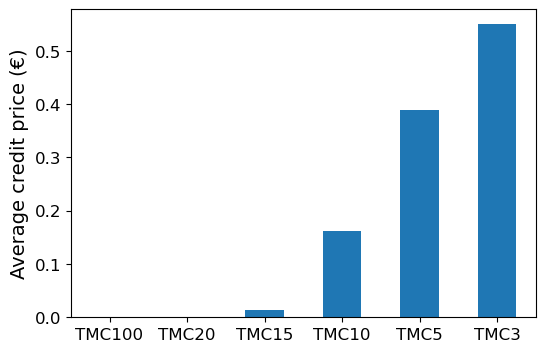

In [8]:
price_dict = dict()
tmc_labels = []
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        tmc_labels.append(scheme.replace("tmc", "TMC"))
        price_dict[scheme] = evo_df[scheme].price.mean() 

price_dict = {k:[v] for k,v in price_dict.items()}
ax = pd.DataFrame(price_dict).T.plot(kind='bar', figsize=(6, 4), legend=False)
ax.set_xticklabels(tmc_labels, rotation=0, fontsize=12)
ax.tick_params(axis='y', labelsize=12)
# Adding labels and title to the plot
# plt.xlabel('TMC Scenarios')
plt.ylabel('Average credit price (€)', fontsize=14)
# plt.title('Average Credit Price for TMC Scenarios')

plt.savefig(os.path.join(path, 'plots', str(repl_id),'avg_credit_price.png'), facecolor='w')
# Displaying the plot
plt.show()

In [9]:
evo_df['tmc10'].price
pd.DataFrame(price_dict)

,tmc100,tmc20,tmc15,tmc10,tmc5,tmc3
0,0.0,0.0,0.013857,0.161714,0.388714,0.550429


,tmc100,tmc20,tmc15,tmc10,tmc5,tmc3
car,26.192146,26.192146,25.525947,17.241034,8.505310,5.139251
rh_solo,1.989832,1.718093,1.572831,0.581046,0.190343,0.140252
rh_pool,6.127279,6.355189,6.692046,6.241234,5.319575,4.387898
pt,4.479313,4.260168,4.217592,4.077339,3.516329,3.045482
bike,61.211431,61.474404,61.991585,71.859347,82.468443,87.287117
not_enough_credit,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


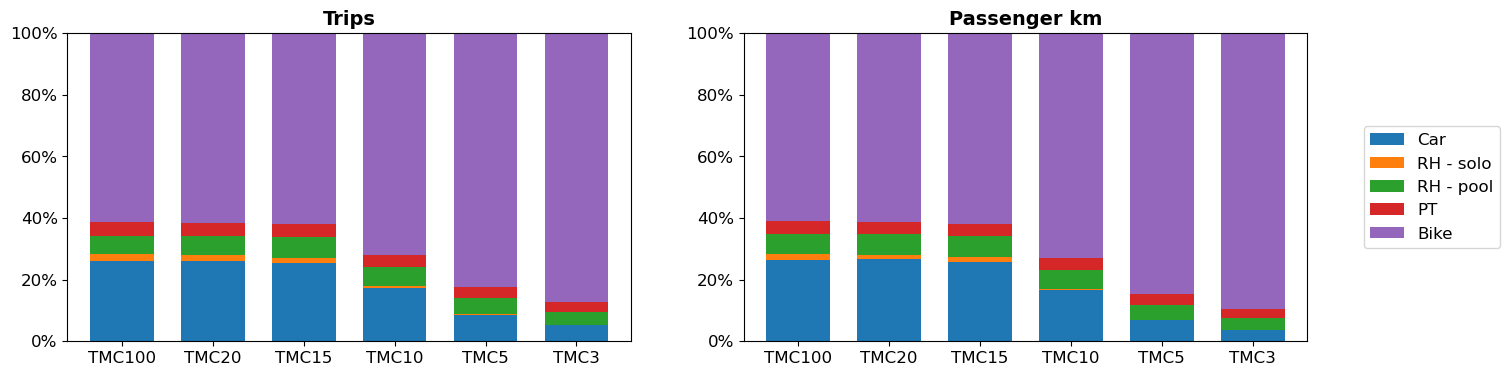

In [10]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

### Determine average indicators for TMC scenario - market share in trips
modal_split_trips = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    # if not scheme.startswith('tmc'):
    modal_split_trips[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_days_eql).sum(axis=0).div(evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_days_eql).sum().sum()).mul(100)
    # else:
    #     modal_split_trips[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_dayssum().div(n_days_eql).mul(100)
modal_split_trips.T.plot.bar(stacked=True, rot=0, ax=axes[0], width=0.7)
axes[0].get_legend().remove()
axes[0].set_xticklabels(dem_mgmt_labels)
axes[0].set_title('Trips', fontweight='bold', fontsize=14)
axes[0].set_ylim(0,100)
axes[0].yaxis.set_major_formatter(mtick.PercentFormatter())
modal_split_trips

### Determine average indicators for TMC scenario - market share in pax km
modal_split_paxkm = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    df = evo_df[scheme][['paxkm_car','paxkm_solo','paxkm_pool','paxkm_pt', 'paxkm_bike']]
    # if not scheme.startswith('tmc'):
    modal_split_paxkm[scheme] = df.tail(n_days_eql).sum(axis=0).div(df.tail(n_days_eql).sum().sum()).mul(100)
    # else:
        # modal_split_paxkm[scheme] = df.sum(axis=0).div(df.sum().sum()).mul(100)
modal_split_paxkm.T.plot.bar(stacked=True, ax=axes[1], width=0.7, rot=0)
axes[1].set_xticklabels(dem_mgmt_labels, fontsize=12)
axes[1].legend(labels=mode_labels, bbox_to_anchor=(1.1, 0.5), loc="center left", borderaxespad=0, fontsize=12)
axes[1].set_title('Passenger km', fontweight='bold', fontsize = 14)
axes[1].set_ylim(0,100)
axes[1].yaxis.set_major_formatter(mtick.PercentFormatter())
modal_split_paxkm

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=12)

alpha_array = np.array([1.0 if name.startswith('tmc') else 0.6 for name in dem_mgmt_schemes])
# Apply transparency conditionally for each bar segment
for container in axes[0].containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])
for container in axes[1].containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])

plt.savefig(os.path.join(path, 'plots', str(repl_id),'market-shares.png'), facecolor='w')

modal_split_trips

In [11]:
evo_df['tmc10'][['paxkm_car','paxkm_solo','paxkm_pool','paxkm_pt', 'paxkm_bike']].tail(n_days_eql).sum().div(n_days_eql)

paxkm_car      979.058464
paxkm_solo      24.200453
paxkm_pool     371.766835
paxkm_pt       235.470208
paxkm_bike    4317.389571
dtype: float64

,tmc100,tmc20,tmc15,tmc10,tmc5,tmc3
car,26.192146,26.192146,25.525947,17.241034,8.505310,5.139251
rh_solo,1.989832,1.718093,1.572831,0.581046,0.190343,0.140252
rh_pool,6.127279,6.355189,6.692046,6.241234,5.319575,4.387898
pt,4.479313,4.260168,4.217592,4.077339,3.516329,3.045482
bike,61.211431,61.474404,61.991585,71.859347,82.468443,87.287117
not_enough_credit,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


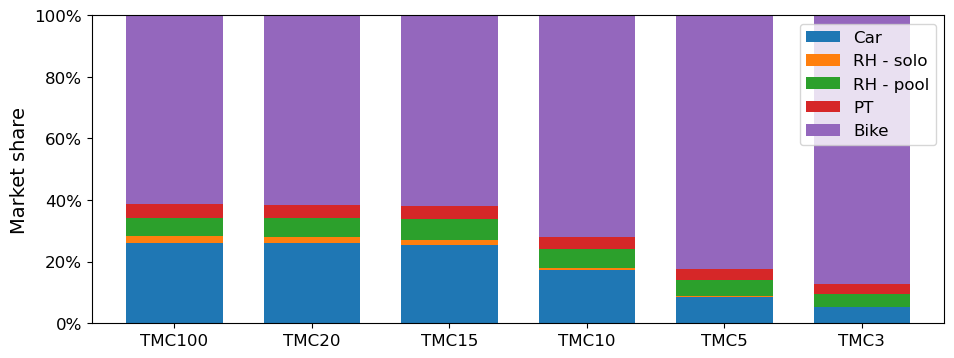

In [12]:
# fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 4))

### Determine average indicators for TMC scenario - market share in trips
modal_split_trips = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    # if not scheme.startswith('tmc'):
    modal_split_trips[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_days_eql).sum().div(evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_days_eql).sum().sum(), axis=0).mul(100)
    # else:
    # modal_split_trips[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].sum().div(params[scheme]['nP']*params[scheme]['tmc']['duration']).mul(100)
ax = modal_split_trips.T.plot.bar(stacked=True, rot=0, width=0.7, figsize=(11,4))
ax.get_legend().remove()
ax.set_xticklabels(dem_mgmt_labels)
ax.set_ylim(0,100)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(mode_labels, fontsize=12)
modal_split_trips

ax.set_ylabel('Market share', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)

alpha_array = np.array([1.0 if name.startswith('tmc') else 0.6 for name in dem_mgmt_schemes])
# Apply transparency conditionally for each bar segment
for container in ax.containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])

plt.savefig(os.path.join(path, 'plots', str(repl_id),'market-shares_trips_only.png'), facecolor='w')

modal_split_trips

In [13]:
# ## Market share in trips for which the shortest path by car traverses the city centre
# modal_split_trips_center = pd.DataFrame()
# for scheme in dem_mgmt_schemes:
#     if not scheme.startswith('tmc'):
#         modal_split_trips_center[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].tail(n_days_eql).sum().div(params[scheme]['nP']*n_days_eql).mul(100)
#     else:
#         modal_split_trips_center[scheme] = evo_df[scheme][['car','rh_solo','rh_pool', 'pt', 'bike','not_enough_credit']].sum().div(params[scheme]['nP']*params[scheme]['tmc']['duration']).mul(100)
# ax = modal_split_trips_center.T.plot.bar(stacked=True, rot=0, width=0.7)
# ax.get_legend().remove()
# ax.set_xticklabels(dem_mgmt_labels)
# ax.set_title('Trips', fontweight='bold', fontsize=14)
# ax.set_ylim(0,100)
# ax.yaxis.set_major_formatter(mtick.PercentFormatter())
# modal_split_trips

<Figure size 3000x600 with 0 Axes>

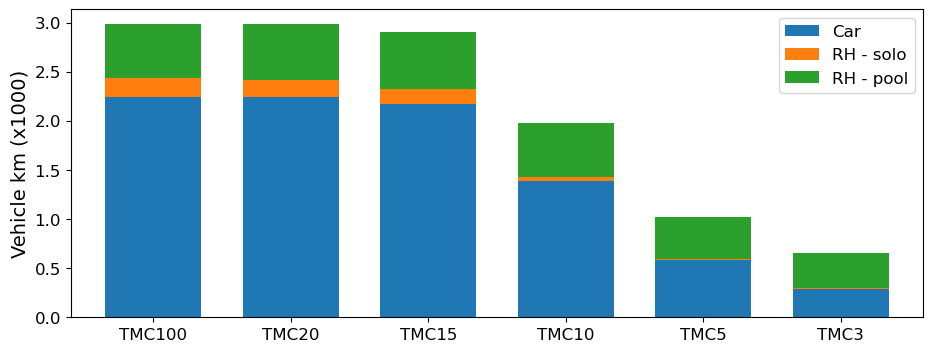

In [14]:
fig = plt.figure(figsize=(30, 6))

# Vehicle kilometres
vkt = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    if not scheme.startswith('tmc'):
        vkt[scheme] = evo_df[scheme][['vkt_car', 'vkt_solo', 'vkt_pool']].tail(n_days_eql).mean()
    else:
        vkt[scheme] = evo_df[scheme][['vkt_car', 'vkt_solo', 'vkt_pool']].mean()
ax = (vkt / 1000).T.plot.bar(stacked=True, rot=0, width=0.7, figsize=(11, 4))
ax.set_xticklabels(dem_mgmt_labels, fontsize=12)
ax.set_ylabel('Vehicle km (x1000)', fontsize=14)
ax.legend(labels=['Car', 'RH - solo', 'RH - pool'], fontsize=12)

alpha_array = np.array([1.0 if name.startswith('tmc') else 0.5 for name in dem_mgmt_schemes])
# Apply transparency conditionally for each bar segment
for container in ax.containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])

ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'vkt.png'), facecolor='w')

C:\Users\arjanderuijter\AppData\Local\Temp\ipykernel_28916\3556901075.py:11: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  co2[scheme]['alpha'] = 0.5
C:\Users\arjanderuijter\AppData\Local\Temp\ipykernel_28916\3556901075.py:11: FutureWarning:

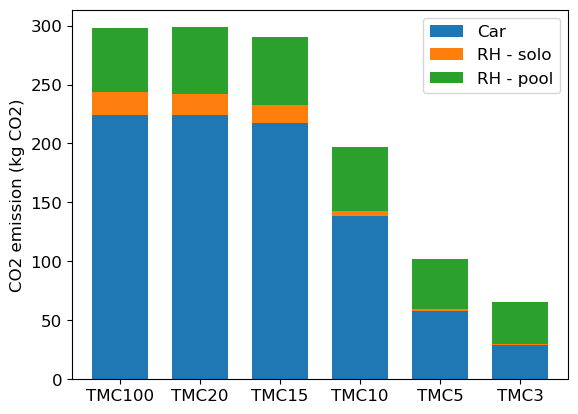

In [15]:
# CO2 emissions
co2 = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    if not scheme.startswith('tmc'):
        co2[scheme] = evo_df[scheme][['vkt_car', 'vkt_solo', 'vkt_pool']].tail(n_days_eql).mean() * 0.1 * 1000 # kg CO2
        # co2[scheme]['pt'] = evo_df[scheme]['paxkm_pt'].tail(n_days_eql).mean() * 0.04 # kg CO2
        co2[scheme]['alpha'] = 1
    else:
        co2[scheme] = evo_df[scheme][['vkt_car', 'vkt_solo', 'vkt_pool']].mean() * 0.1 * 1000 # kg CO2
        # co2[scheme] = evo_df[scheme][['paxkm_pt']].mean() * 0.04 # kg CO2
        co2[scheme]['alpha'] = 0.5
ax = (co2 / 1000).T.plot.bar(stacked=True, rot=0, width=0.7)
ax.set_xticklabels(dem_mgmt_labels, fontsize=12)
ax.set_ylabel('CO2 emission (kg CO2)', fontsize=12)
ax.legend(labels=['Car', 'RH - solo', 'RH - pool'], fontsize=12)

# col_names = co2.columns.values.tolist()
alpha_array = np.array([1.0 if name.startswith('tmc') else 0.5 for name in dem_mgmt_schemes])
# Apply transparency conditionally for each bar segment
for container in ax.containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])
# # Apply transparency conditionally
# for bar, alpha in zip(ax.patches, alpha_array):
#     print(bar, alpha)
#     bar.set_alpha(alpha)


ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'co2.png'), facecolor='w')
# (co2 / co2['None'].sum()).sum(axis=0)

In [16]:
co2

,tmc100,tmc20,tmc15,tmc10,tmc5,tmc3
vkt_car,224260.528788,224444.813925,217278.524857,138301.689514,57918.722171,29161.191157
vkt_solo,19233.714450,17372.365888,15193.214600,4670.242571,1278.971271,842.433086
vkt_pool,54840.518640,56739.873668,58130.556375,54392.254995,42833.027184,35841.187667


,tmc100,tmc20,tmc15,tmc10,tmc5,tmc3
total_perc_gtt,1.0,1.0,1.0,1.0,1.0,1.0


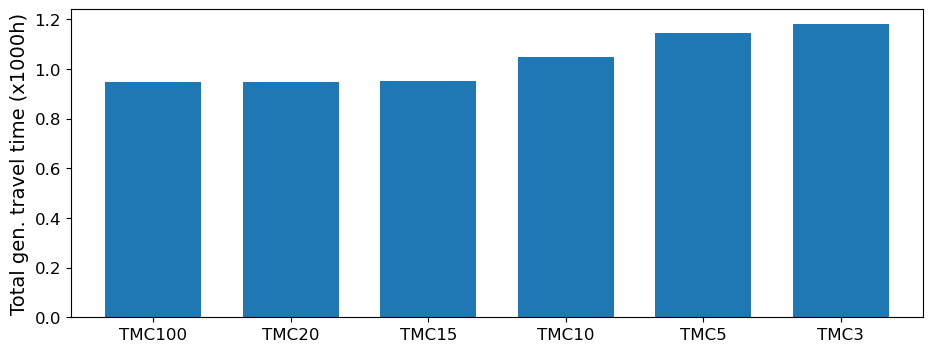

In [17]:
# Perceived gtt
perc_gtt = pd.DataFrame()
for scheme in dem_mgmt_schemes:
    if not scheme.startswith('tmc'):
        perc_gtt[scheme] = evo_df[scheme][['total_perc_gtt']].tail(n_days_eql).mean()
    else:
        perc_gtt[scheme] = evo_df[scheme][['total_perc_gtt']].mean()
ax = (perc_gtt / 1000).T.plot.bar(rot=0, width=0.7, figsize=(11,4))
ax.set_xticklabels(dem_mgmt_labels, fontsize=12)

alpha_array = np.array([1.0 if name.startswith('tmc') else 0.5 for name in dem_mgmt_schemes])
# Apply transparency conditionally for each bar segment
for container in ax.containers:
    for i, bar in enumerate(container):
        bar.set_alpha(alpha_array[i])

ax.get_legend().remove()
ax.set_ylabel('Total gen. travel time (x1000h)', fontsize=14)
ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'gtt.png'), facecolor='w')

perc_gtt / perc_gtt.loc['total_perc_gtt']

## From hereon we look at individual travellers properties (experienced and expected)

In [18]:
# TMC - Indicators on last day, and passenger properties
travs_df = dict()
pax_prop = dict()
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        last_day = evo_df[scheme].index.values[-1]
        folder = os.path.join(result_path, '{}-{}'.format(scheme, scenario_name))
        pattern = f"mc_{last_day}_tm_*.csv"
        files = glob.glob(os.path.join(folder, pattern))
        # Extract tm numbers
        tm_numbers = []
        for f in files:
            match = re.search(r"mc_{}_tm_(\d+)\.csv".format(last_day), os.path.basename(f))
            if match:
                tm_numbers.append(int(match.group(1)))
        if tm_numbers:
            last_tm = max(tm_numbers)
        else:
            last_tm = 0  # fallback if nothing found
        travs_df[scheme] = pd.read_csv(os.path.join(result_path, '{}-{}'.format(scheme, scenario_name), 'mc_{}_tm_{}_travs.csv'.format(last_day, last_tm))).reset_index()
        pax_prop = pd.read_csv(os.path.join(result_path, '{}-{}'.format(scheme, scenario_name), '1_pax-properties.csv'))
        pax_prop = pax_prop.loc[pax_prop['pax_id'].isin(travs_df[scheme]['pax'].unique())].copy().reset_index()
        expected_pax_prop = pd.read_csv(os.path.join(result_path, '{}-{}'.format(scheme, scenario_name), 'conv_trav_expected_attr.csv'))
        expected_pax_prop = expected_pax_prop.loc[expected_pax_prop['Unnamed: 0'].isin(travs_df[scheme]['pax'].unique())].copy().reset_index()
        travs_df[scheme] = pd.concat([travs_df[scheme], pax_prop, expected_pax_prop], axis=1)
        travs_df[scheme]['credits_bought'] = travs_df[scheme]['credits'] - travs_df[scheme]['tmc_balance']
        travs_df[scheme]['money_spent_buying_credits'] = travs_df[scheme]['credits_bought'] * evo_df[scheme]['price'].iloc[-1]
travs_df['tmc10']

,index,pax,chosen_mode,time_occ_1,time_occ_2,time_occ_3,informed,xp_ttf,expected_ttf,days_since_reg,...,zone_id,rh_zone,index,Unnamed: 0,gtt,cost,credits,constant,credits_bought,money_spent_buying_credits
0,0,1,car,NaN,NaN,NaN,True,1.0,1.0,5,...,0,2,1,1,568.342861,1.360761,53.798572,-1.031350,43.798572,7.095369
1,1,2,bike,NaN,NaN,NaN,True,1.0,1.0,5,...,0,2,2,2,3331.583987,0.001900,0.074467,5.171259,-9.925533,-1.607936
2,2,3,bike,NaN,NaN,NaN,True,1.0,1.0,5,...,0,2,3,3,2713.404141,0.007839,0.310128,5.688323,-9.689872,-1.569759
3,3,4,bike,NaN,NaN,NaN,True,1.0,1.0,5,...,0,2,4,4,2353.335562,0.000007,0.000083,5.166883,-9.999917,-1.619987
4,4,5,bike,NaN,NaN,NaN,True,1.0,1.0,5,...,0,2,5,5,3182.362094,0.001188,0.006139,1.385837,-9.993861,-1.619006
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1421,1421,1818,bike,NaN,NaN,NaN,True,1.0,1.0,5,...,15,2,1818,1818,1962.959781,0.037363,1.075102,-2.537788,-8.924898,-1.445834
1422,1422,1819,bike,NaN,NaN,NaN,True,1.0,1.0,5,...,15,2,1819,1819,2110.553633,1.355842,6.959006,-4.173867,-3.040994,-0.492641
1423,1423,1820,bike,NaN,NaN,NaN,True,1.0,1.0,5,...,9,2,1820,1820,1562.267038,0.000358,0.014501,8.368180,-9.985499,-1.617651
1424,1424,1821,bike,NaN,NaN,NaN,True,1.0,1.0,5,...,15,2,1821,1821,1913.715625,0.271459,9.978959,0.320847,-0.021041,-0.003409


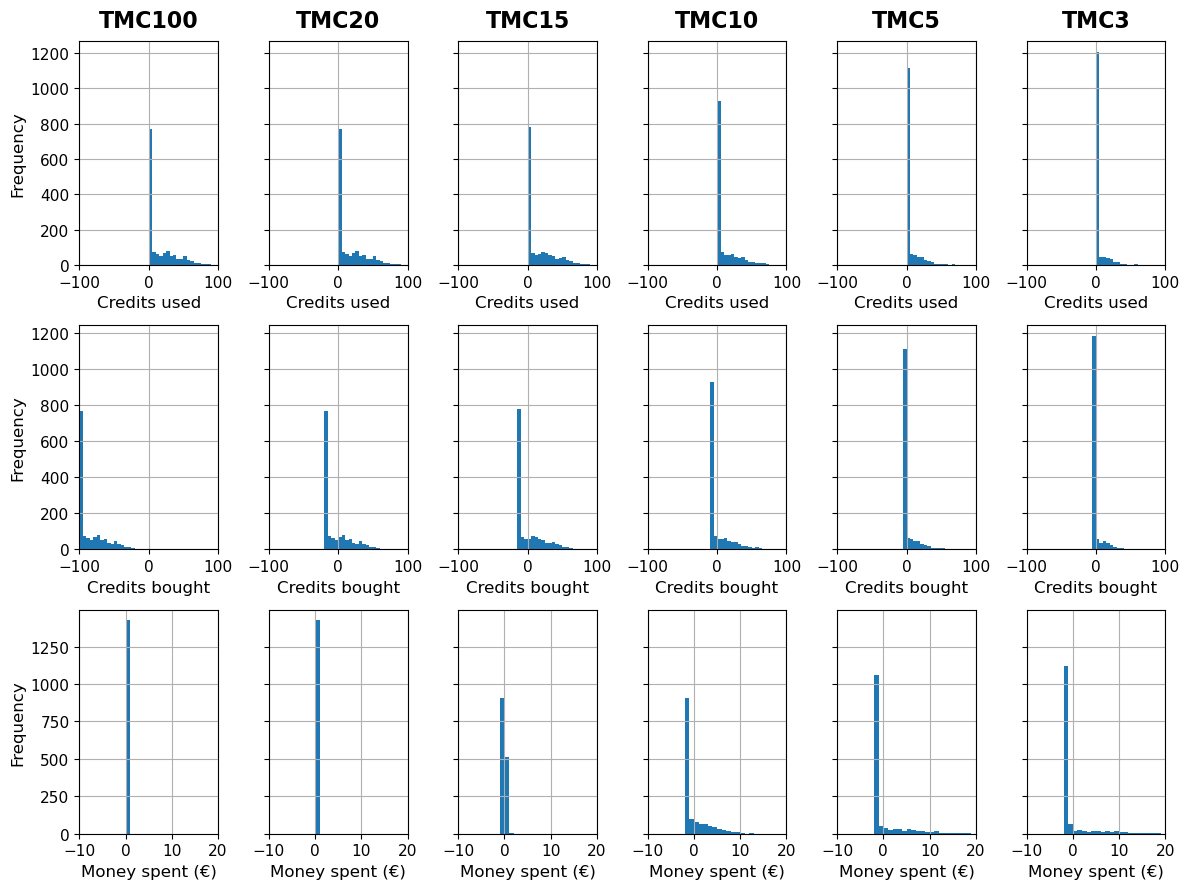

In [20]:
fig, axes = plt.subplots(nrows=3, ncols=n_tmc_scenarios, figsize=(12, 9), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        travs_df[scheme].credits.hist(ax=axes[0,i],bins=range(-100, 100, 5))
        axes[0, i].set_xlim(-100,100)
        axes[0, i].set_xlabel('Credits used', fontsize=12)

        travs_df[scheme].credits_bought.hist(ax=axes[1,i],bins=range(-100, 100, 5))
        axes[1, i].set_xlim(-100,100)
        axes[1, i].set_xlabel('Credits bought', fontsize=12)

        travs_df[scheme].money_spent_buying_credits.hist(ax=axes[2,i], bins=range(-10, 20, 1))
        axes[2, i].set_xlabel('Money spent (€)', fontsize=12)
        axes[2, i].set_xlim(-10,20)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
axes[0, 0].set_ylabel('Frequency', fontsize=12)
axes[1, 0].set_ylabel('Frequency', fontsize=12)
axes[2, 0].set_ylabel('Frequency', fontsize=12)

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)

fig.tight_layout()
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'balance-distr.png'), facecolor='w')

In [21]:
evo_df[scheme]['price'].iloc[-1]

np.float64(0.552)

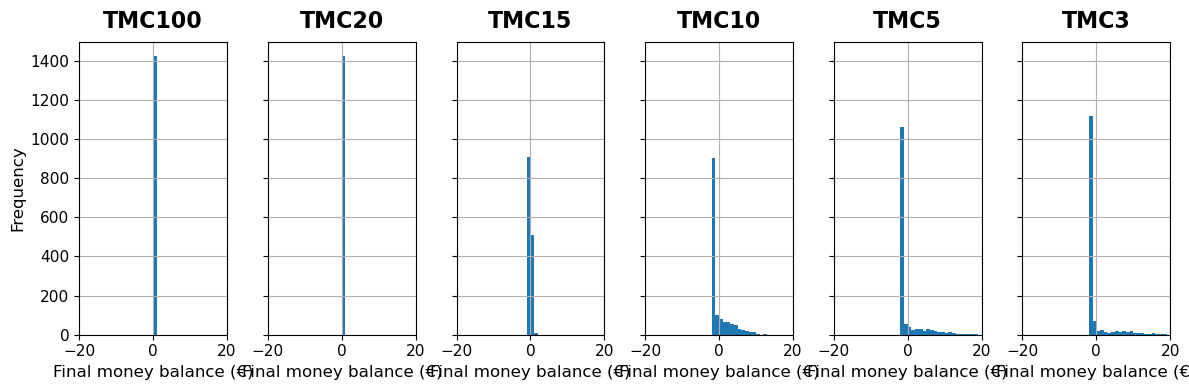

In [22]:
fig, axes = plt.subplots(nrows=1, ncols=n_tmc_scenarios, figsize=(12, 4), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        travs_df[scheme].money_spent_buying_credits.hist(ax=axes[i], bins=range(-20, 20, 1))
        axes[i].set_xlabel('Final money balance (€)', fontsize=12)
        axes[i].set_xlim(-20,20)

        # Subtitle for scheme
        axes[i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
axes[0].set_ylabel('Frequency', fontsize=12)
# axes[1, 0].set_ylabel('Frequency', fontsize=12)

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)

fig.tight_layout()
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'money-balance-distr.png'), facecolor='w')

C:\Users\arjanderuijter\AppData\Local\Temp\ipykernel_28916\108696562.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


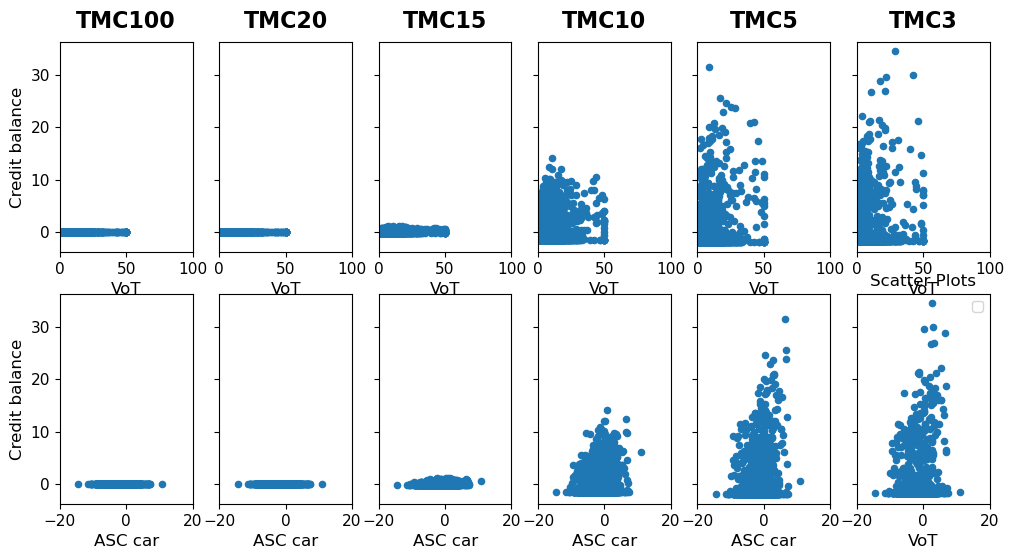

In [23]:
fig, axes = plt.subplots(nrows=2, ncols=n_tmc_scenarios, figsize=(12, 6), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        travs_df[scheme].plot.scatter(x='VoT',y='money_spent_buying_credits', ax=axes[0,i])
        axes[0, i].set_xlim(0,100)
        axes[0, i].set_xlabel('VoT', fontsize=12)

        travs_df[scheme].plot.scatter(x='ASC_car',y='money_spent_buying_credits', ax=axes[1,i])
        axes[1, i].set_xlabel('ASC car', fontsize=12)
        axes[1, i].set_xlim(-20,20)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
axes[0, 0].set_ylabel('Credit balance', fontsize=12)
axes[1, 0].set_ylabel('Credit balance', fontsize=12)

for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)


# Get the columns starting with 'ASC'
asc_columns = [col for col in df.columns if col.startswith('ASC')]

# Create scatter plots
for column in asc_columns:
    plt.scatter(df['VoT'], df[column], label=column)

# Set labels and title
plt.xlabel('VoT')
plt.ylabel('net_purchase')
plt.title('Scatter Plots')
plt.legend()

# Show the plot
plt.show()

In [24]:
# fig, axes = plt.subplots(nrows=1, ncols=n_tmc_scenarios, figsize=(12, 6), sharey='row', sharex=True)
# i = 0
# for scheme in dem_mgmt_schemes:
#     if scheme.startswith("tmc"):
#         travs_df[scheme].money_balance.hist(ax=axes[i])
#         i+=1
# # travs_df.money_balance.hist(bins=20)

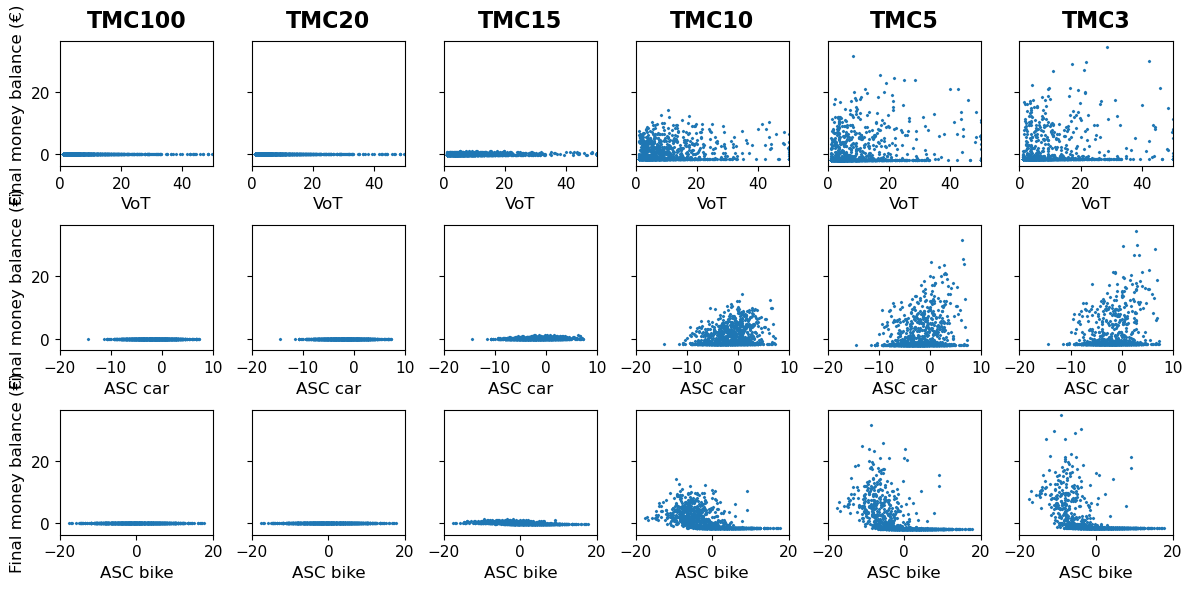

In [25]:
fig, axes = plt.subplots(nrows=3, ncols=n_tmc_scenarios, figsize=(12, 6), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        travs_df[scheme].plot.scatter(x='VoT', y='money_spent_buying_credits', marker='x', s=2, ax=axes[0, i])
        axes[0, i].set_xlabel('VoT', fontsize=12)
        axes[0, i].set_ylabel('Final money balance (€)', fontsize=12)
        axes[0, i].set_xlim(0,50)
        
        travs_df[scheme].plot.scatter(x='ASC_car', y='money_spent_buying_credits', marker='x', s=2, ax=axes[1, i])
        axes[1, i].set_xlabel('ASC car', fontsize=12)
        axes[1, i].set_ylabel("Final money balance (€)", fontsize=12)
        axes[1, i].set_xlim(-20,10)

        travs_df[scheme].plot.scatter(x='ASC_bike', y='money_spent_buying_credits', marker='x', s=2, ax=axes[2, i])
        axes[2, i].set_xlabel('ASC bike', fontsize=12)
        axes[2, i].set_ylabel("Final money balance (€)", fontsize=12)
        axes[2, i].set_xlim(-20,20)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
fig.tight_layout()
for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'distr_effects.png'), facecolor='w')

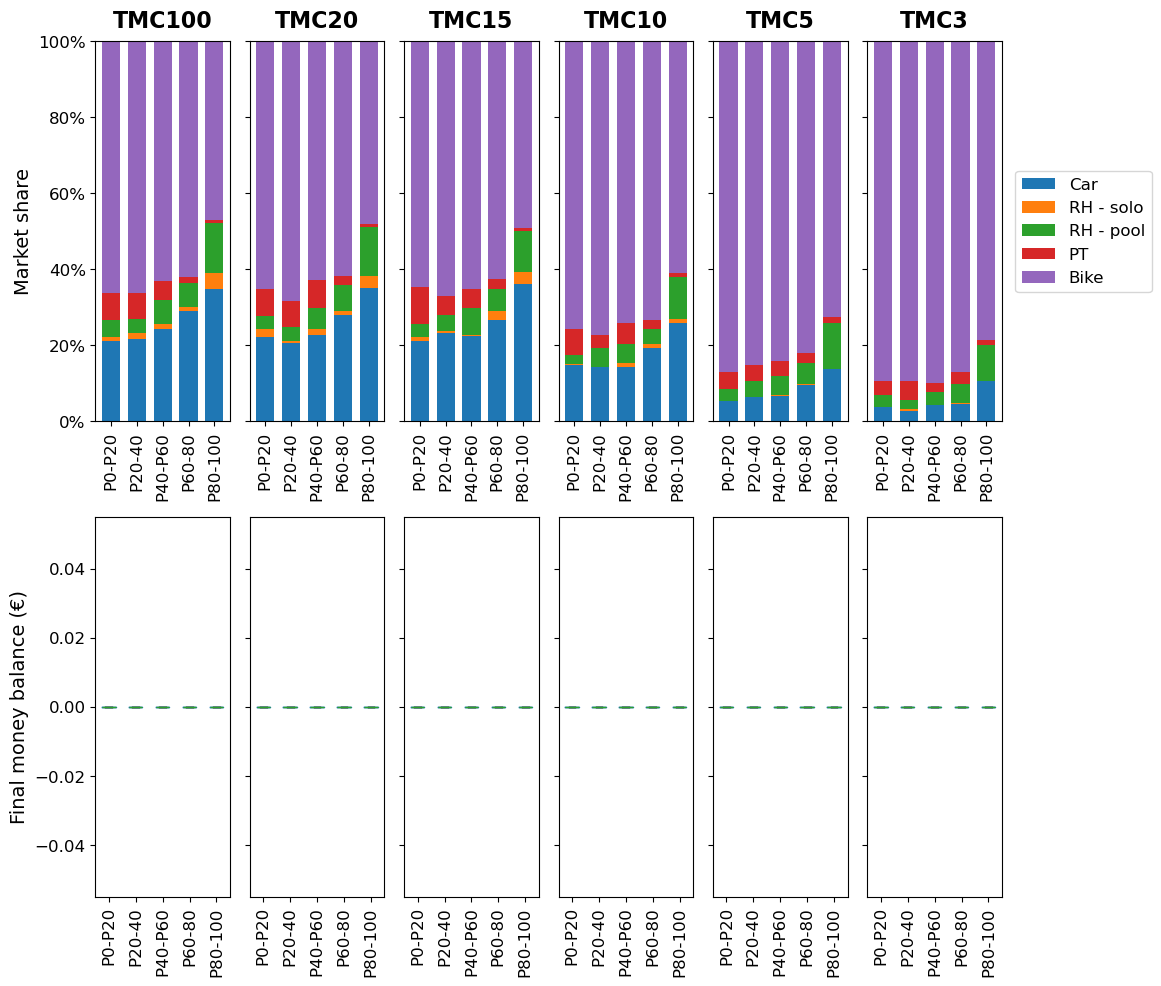

In [26]:
fig, axes = plt.subplots(nrows=2, ncols=n_tmc_scenarios, figsize=(12, 10), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        df = travs_df[scheme].copy()
        df['VoT_group'] = pd.qcut(travs_df[scheme]['VoT'], q=5, labels=['P0-P20', 'P20-40', 'P40-P60', 'P60-80', 'P80-100'])

        vot_groups = df['VoT_group'].unique()
        chosen_modes = ['car', 'bike', 'pt', 'rs_0', 'rs_1']  # include rs_0 explicitly

        # Create full MultiIndex
        full_index = pd.MultiIndex.from_product(
        [vot_groups, chosen_modes],
        names=['VoT_group', 'chosen_mode']
        )

        # Group and normalize to percentages
        counts = df.groupby(['VoT_group', 'chosen_mode'], observed=False).size()
        counts = counts.reindex(full_index, fill_value=0)

        # Convert to % of group (assuming equal group size)
        pivot_table = (counts.unstack() / (len(df) / len(vot_groups))) * 100

        # Plot
        pivot_table[['car','rs_0','rs_1','pt','bike']].plot(
        kind='bar',
        stacked=True,
        ax=axes[0, i],
        width=0.7
        )
        axes[0, i].yaxis.set_major_formatter(mtick.PercentFormatter())
        axes[0, i].set_ylim(0,100)
        axes[0, i].set_xlabel('')
        axes[0, i].tick_params(axis='y', which='major', labelsize=20)
        # mean_money_per_group = df.groupby('VoT_group')['money_balance'].mean()
        # mean_money_per_group.plot(kind='bar', stacked=True, ax=axes[1, i])

        df.boxplot(column='money_balance', by='VoT_group', grid=False, ax=axes[1, i], whis=[0,100])

        if i == n_tmc_scenarios-1:
            axes[0, i].legend(labels=mode_labels, bbox_to_anchor=(1.1, 0.5), loc="center left", borderaxespad=0, fontsize=12)
        else:
            axes[0, i].get_legend().remove()
        axes[1, i].set_title('')
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=90)  # Change '45' to your desired rotation angle
        axes[1, i].set_xlabel('')

        if False:
            df['ASC_car_group'] = pd.qcut(travs_df[scheme]['ASC_car'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
            pivot_table_asc_car = df.groupby(['ASC_car_group', 'chosen_mode']).size().unstack(fill_value=0)
            pivot_table_asc_car.plot(kind='bar', stacked=True, ax=axes[2, i])
            df.boxplot(column='money_balance', by='ASC_car_group', grid=False, ax=axes[3, i])

        
        # travs_df[scheme].plot.scatter(x='VoT', y='money_balance', marker='x', s=2, ax=axes[0, i])
        # axes[0, i].set_xlabel('VoT', fontsize=12)
        axes[0, i].set_ylabel('Market share', fontsize=14)
        # axes[0, i].set_xlim(0,150)
        
        # travs_df[scheme].plot.scatter(x='ASC_car', y='money_balance', marker='x', s=2, ax=axes[1, i])
        # axes[1, i].set_xlabel('ASC car', fontsize=12)
        axes[1, i].set_ylabel("Final money balance (€)", fontsize=14)
        # axes[1, i].set_xlim(-20,10)

        # travs_df[scheme].plot.scatter(x='ASC_bike', y='money_balance', marker='x', s=2, ax=axes[2, i])
        # axes[2, i].set_xlabel('ASC bike', fontsize=12)
        # axes[2, i].set_ylabel("Final money balance (€)", fontsize=12)
        # axes[2, i].set_xlim(-20,20)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
fig.suptitle('')
fig.tight_layout(h_pad=2)
for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'market-share-vot.png'), facecolor='w')

chosen_mode,bike,car,pt,rs_0,rs_1
VoT_group,,,,,
P0-P20,87.307153,5.259467,4.558205,0.000000,3.155680
P20-40,85.203366,6.311360,4.207574,0.000000,4.207574
P40-P60,84.151473,6.661992,3.856942,0.350631,4.908836
P60-80,82.047686,9.467041,2.454418,0.350631,5.610098
P80-100,72.580645,13.674614,1.402525,0.000000,12.272090


C:\Users\arjanderuijter\AppData\Local\Temp\ipykernel_28916\1993521805.py:79: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(monetary_vot['tmc10'].groupby('VoT_group')['money_balance'].mean())


VoT_group
P0-P20     0.0
P20-40     0.0
P40-P60    0.0
P60-80     0.0
P80-100    0.0
Name: money_balance, dtype: float64

C:\Users\arjanderuijter\AppData\Local\Temp\ipykernel_28916\1993521805.py:80: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  display(monetary_vot['tmc5'].groupby('VoT_group')['money_balance'].mean())


VoT_group
P0-P20     0.0
P20-40     0.0
P40-P60    0.0
P60-80     0.0
P80-100    0.0
Name: money_balance, dtype: float64

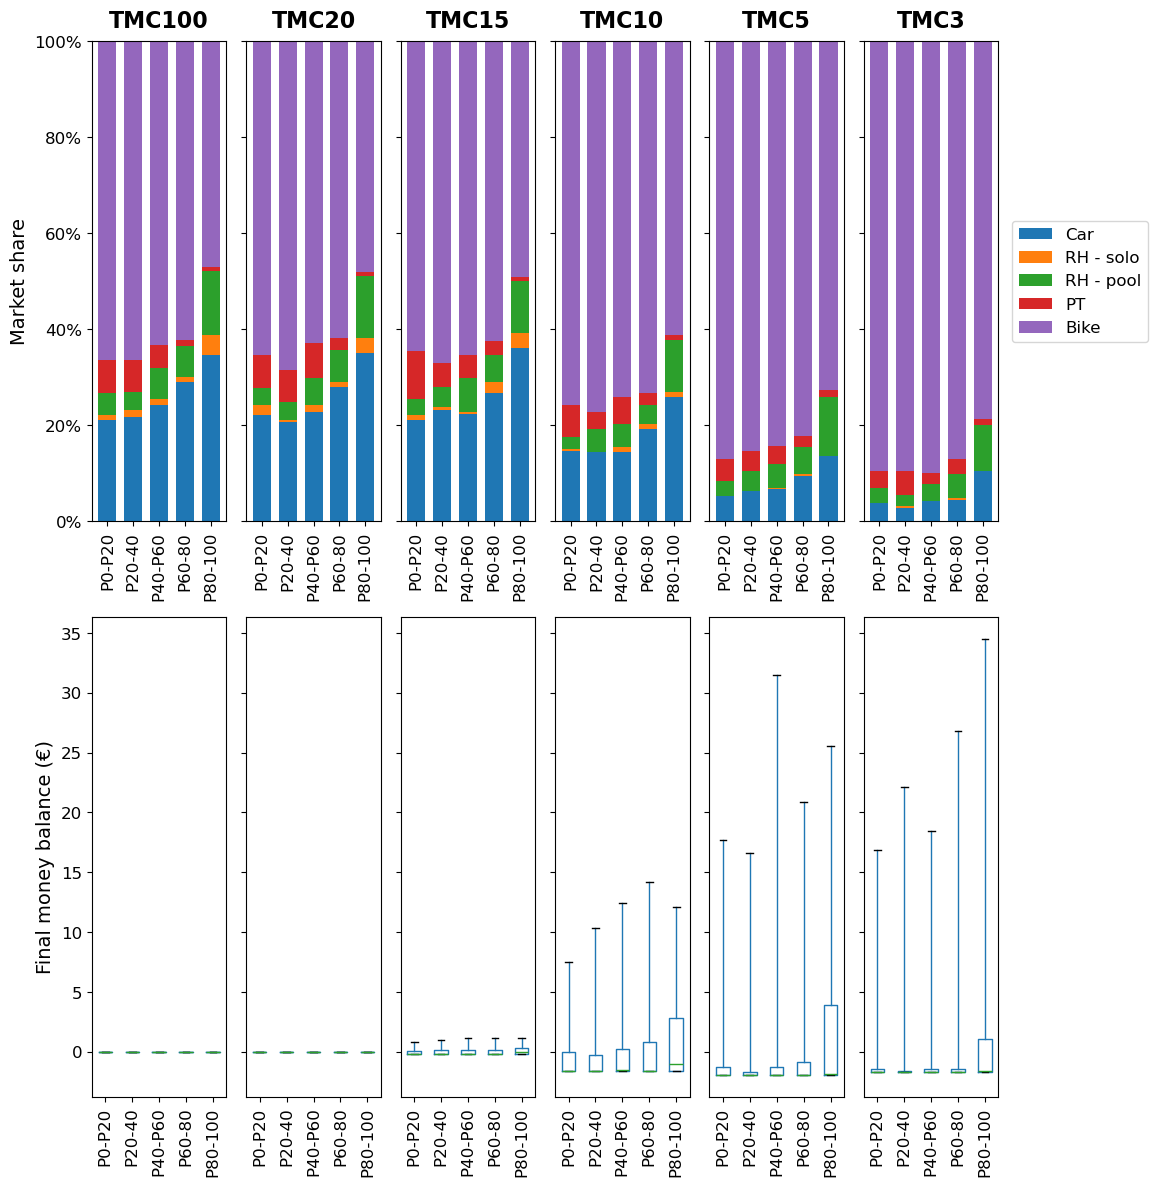

In [27]:
fig, axes = plt.subplots(nrows=2, ncols=n_tmc_scenarios, figsize=(12, 12), sharey='row')
ms_vot = dict()
monetary_vot = dict()
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        df = travs_df[scheme].copy()
        df['VoT_group'] = pd.qcut(travs_df[scheme]['VoT'], q=5, labels=['P0-P20', 'P20-40', 'P40-P60', 'P60-80', 'P80-100'])

        vot_groups = df['VoT_group'].unique()
        chosen_modes = ['car', 'bike', 'pt', 'rs_0', 'rs_1']  # include rs_0 explicitly

        # Create full MultiIndex
        full_index = pd.MultiIndex.from_product(
        [vot_groups, chosen_modes],
        names=['VoT_group', 'chosen_mode']
        )

        # Group and normalize to percentages
        ms_vot[scheme] = df.groupby(['VoT_group', 'chosen_mode'], observed=False).size()
        ms_vot[scheme] = ms_vot[scheme].reindex(full_index, fill_value=0).unstack(fill_value=0) / (len(df) / 5) * 100

        # # Convert to % of group (assuming equal group size)
        # pivot_table = (counts.unstack() / (len(df) / len(vot_groups))) * 100

        # ms_vot[scheme] = df.groupby(['VoT_group', 'chosen_mode']).size().unstack(fill_value=0) / (len(df) / 5) * 100
        ms_vot[scheme][['car','rs_0','rs_1', 'pt', 'bike']].plot(kind='bar', stacked=True, ax=axes[0, i], width=0.7)
        axes[0, i].yaxis.set_major_formatter(mtick.PercentFormatter())
        axes[0, i].set_ylim(0,100)
        axes[0, i].set_xlabel('')
        axes[0, i].tick_params(axis='y', which='major', labelsize=20)
        # mean_money_per_group = df.groupby('VoT_group')['money_balance'].mean()
        # mean_money_per_group.plot(kind='bar', stacked=True, ax=axes[1, i])

        # df['money_balance'] = df['net_purchase'] * evo_df[scheme]['price'].iloc[-1]
        df.boxplot(column='money_spent_buying_credits', by='VoT_group', grid=False, ax=axes[1, i], whis=[0,100])
        monetary_vot[scheme] = df.copy()

        if i == n_tmc_scenarios-1:
            axes[0, i].legend(labels=mode_labels, bbox_to_anchor=(1.1, 0.5), loc="center left", borderaxespad=0, fontsize=12)
        else:
            axes[0, i].get_legend().remove()
        axes[1, i].set_title('')
        axes[1, i].set_xticklabels(axes[1, i].get_xticklabels(), rotation=90)  # Change '45' to your desired rotation angle
        axes[1, i].set_xlabel('')

        if False:
            df['ASC_car_group'] = pd.qcut(travs_df[scheme]['ASC_car'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
            pivot_table_asc_car = df.groupby(['ASC_car_group', 'chosen_mode']).size().unstack(fill_value=0)
            pivot_table_asc_car.plot(kind='bar', stacked=True, ax=axes[2, i])
            df.boxplot(column='money_balance', by='ASC_car_group', grid=False, ax=axes[3, i])

        
        # travs_df[scheme].plot.scatter(x='VoT', y='money_balance', marker='x', s=2, ax=axes[0, i])
        # axes[0, i].set_xlabel('VoT', fontsize=12)
        axes[0, i].set_ylabel('Market share', fontsize=14)
        # axes[0, i].set_xlim(0,150)
        
        # travs_df[scheme].plot.scatter(x='ASC_car', y='money_balance', marker='x', s=2, ax=axes[1, i])
        # axes[1, i].set_xlabel('ASC car', fontsize=12)
        axes[1, i].set_ylabel("Final money balance (€)", fontsize=14)
        # axes[1, i].set_xlim(-20,10)

        # travs_df[scheme].plot.scatter(x='ASC_bike', y='money_balance', marker='x', s=2, ax=axes[2, i])
        # axes[2, i].set_xlabel('ASC bike', fontsize=12)
        # axes[2, i].set_ylabel("Final money balance (€)", fontsize=12)
        # axes[2, i].set_xlim(-20,20)

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC").replace("_lic", "-LIC").replace("_p", "-P")), fontweight='bold', pad=10, fontsize=16)

        i+=1
fig.suptitle('')
fig.tight_layout(h_pad=2)
for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=12)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'market-share-vot.png'), facecolor='w')
display(ms_vot['tmc5'])
display(monetary_vot['tmc10'].groupby('VoT_group')['money_balance'].mean())
display(monetary_vot['tmc5'].groupby('VoT_group')['money_balance'].mean())

In [28]:
def determine_preferred_mode(travs_df):
    '''determine preferred mode based on ASCs alone'''
    df = travs_df.copy()
    df['preferred_mode'] = df[['ASC_car', 'ASC_rs', 'ASC_pt', 'ASC_bike']].idxmax(axis=1)
    df['preferred_mode'] = df['preferred_mode'].apply(lambda x: x.split('_')[1])
    return df['preferred_mode']

for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        travs_df[scheme]['pref_mode'] = determine_preferred_mode(travs_df[scheme])
travs_df['tmc10']['pref_mode']

0        car
1       bike
2       bike
3       bike
4        car
        ... 
1421    bike
1422      pt
1423    bike
1424    bike
1425    bike
Name: pref_mode, Length: 1426, dtype: object

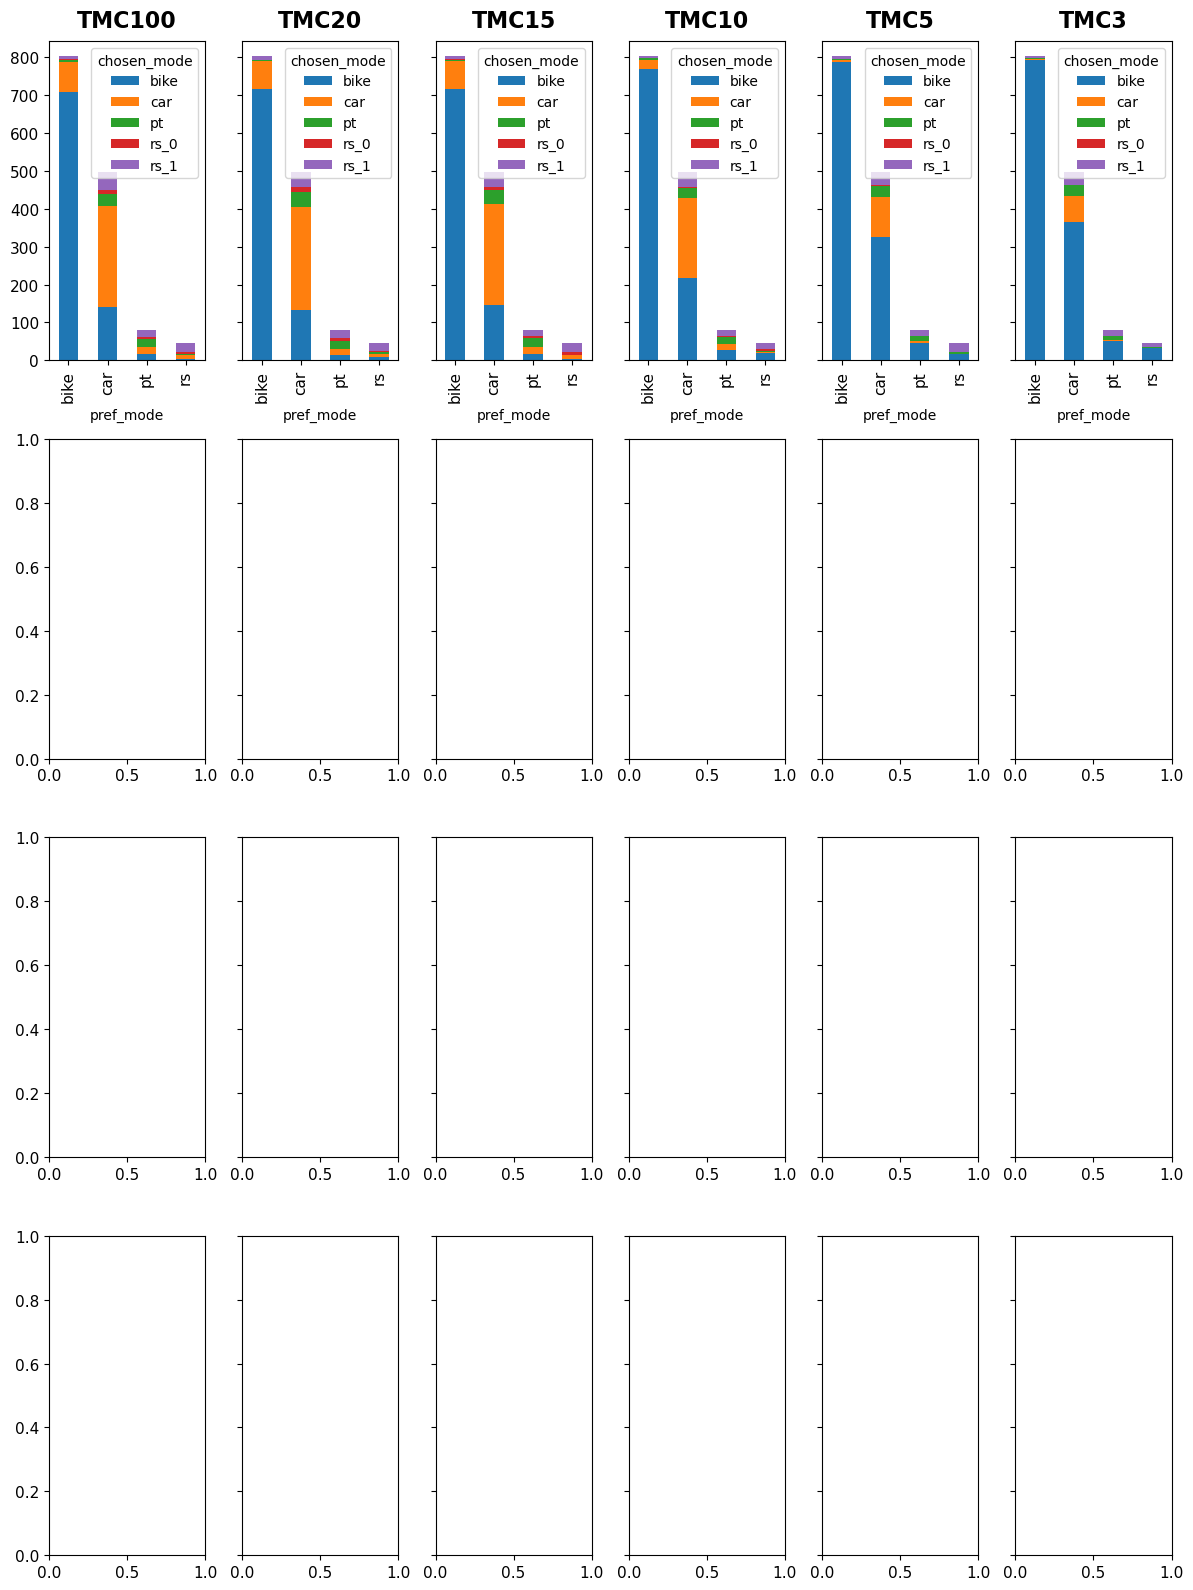

In [29]:
fig, axes = plt.subplots(nrows=4, ncols=n_tmc_scenarios, figsize=(12, 16), sharey='row')
i = 0
for scheme in dem_mgmt_schemes:
    if scheme.startswith("tmc"):
        df = travs_df[scheme].copy()
        # df['pref_mode_group'] = pd.qcut(travs_df[scheme]['preferred_mode'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
        pivot_table = df.groupby(['pref_mode', 'chosen_mode']).size().unstack(fill_value=0)
        pivot_table.plot(kind='bar', stacked=True, ax=axes[0, i])
        
        # mean_money_per_group = df.groupby('VoT_group')['money_balance'].mean()
        # mean_money_per_group.plot(kind='bar', stacked=True, ax=axes[1, i])

        # df.boxplot(column='money_balance', by='VoT_group', grid=False, ax=axes[1, i])

        # df['ASC_car_group'] = pd.qcut(travs_df[scheme]['ASC_car'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'])
        # pivot_table_asc_car = df.groupby(['ASC_car_group', 'chosen_mode']).size().unstack(fill_value=0)
        # pivot_table_asc_car.plot(kind='bar', stacked=True, ax=axes[2, i])

        # df.boxplot(column='money_balance', by='ASC_car_group', grid=False, ax=axes[3, i])

        # Subtitle for scheme
        axes[0, i].set_title('{}'.format(scheme.replace("tmc", "TMC")), fontweight='bold', pad=10, fontsize=16)

        i+=1
fig.tight_layout()
for a in axes.flatten():
    a.tick_params(axis='both', which='major', labelsize=11)
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'market-share-ASC.png'), facecolor='w')

In [30]:
cgp_costs = dict()
for scheme in dem_mgmt_schemes:
    if scheme.startswith("cgp"):
        cgp_costs[scheme] = pd.read_csv(os.path.join(result_path, '{}-{}'.format(scheme, scenario_name), 'day_{}_travs.csv'.format(params[scheme]['nD']-1)))['paid_cgp']
        for day_left in range(2, n_days_eql+1):
            day_df = pd.read_csv(os.path.join(result_path, '{}-{}'.format(scheme, scenario_name), 'day_{}_travs.csv'.format(params[scheme]['nD'] - day_left)))
            cgp_costs[scheme] += day_df['paid_cgp']
        cgp_costs[scheme] = cgp_costs[scheme] / n_days_eql

In [31]:
def count_startswith(lst, prefix):
    return sum(1 for item in lst if item.startswith(prefix))

n_cgp_scenarios = count_startswith(dem_mgmt_schemes, "cgp")

if n_cgp_scenarios > 1:
    fig, axes = plt.subplots(nrows=1, ncols=n_cgp_scenarios, figsize=(12, 4), sharey='row')
    i = 0
    for scheme in dem_mgmt_schemes:
        if scheme.startswith("cgp"):
            cgp_costs[scheme].hist(ax=axes[i], bins=np.arange(0, 10, 1))
            axes[i].set_xlabel('Final money balance (€)', fontsize=12)
            # axes[i].set_xlim(-400,100)

            # Subtitle for scheme
            axes[i].set_title('{}'.format(scheme.replace("cgp", "CGP")), fontweight='bold', pad=10, fontsize=16)

            i+=1
    axes[0].set_ylabel('Frequency', fontsize=12)
    # axes[1, 0].set_ylabel('Frequency', fontsize=12)

    for a in axes.flatten():
        a.tick_params(axis='both', which='major', labelsize=11)

else:
    
    for scheme in dem_mgmt_schemes:
        if scheme.startswith("cgp"):
            cgp_costs[scheme].hist(bins=np.arange(0, 10, 0.25))
            ax.set_xlabel('Final money balance (€)', fontsize=12)
            # ax.set_xlim(-400,100)

            # Subtitle for scheme
            ax.set_title('{}'.format(scheme.replace("cgp", "CGP")), fontweight='bold', pad=10, fontsize=16)
            i+=1
    ax.set_ylabel('Frequency', fontsize=12)
    plt.show()

fig.tight_layout()
plt.savefig(os.path.join(path, 'plots', str(repl_id), 'cgp-paid-distr.png'), facecolor='w')

<Figure size 640x480 with 0 Axes>

In [32]:
travs_df['tmc10'].columns

Index(['index', 'pax', 'chosen_mode', 'time_occ_1', 'time_occ_2', 'time_occ_3',
       'informed', 'xp_ttf', 'expected_ttf', 'days_since_reg', 'tmc_balance',
       'net_purchase', 'denied_order', 'money_balance', 'tot_credit_bought',
       'tot_credit_sold', 'requests_0', 'requests_1', 'gets_offer_0',
       'gets_offer_1', 'accepts_offer_0', 'accepts_offer_1', 'xp_wait_0',
       'xp_wait_1', 'corr_xp_wait_0', 'corr_xp_wait_1', 'xp_ivt_0', 'xp_ivt_1',
       'xp_km_fare_0', 'xp_km_fare_1', 'registered_0', 'registered_1',
       'expected_wait_0', 'expected_wait_1', 'expected_ivt_0',
       'expected_ivt_1', 'expected_km_fare_0', 'expected_km_fare_1', 'index',
       'Unnamed: 0', 'pax_id', 'origin', 'destination', 'treq', 'dist',
       'ttrav_car', 'ttrav_bike', 'PT_ivTime', 'PT_waitingTime', 'PTfare',
       'through_center', 'VoT', 'ASC_rs', 'ASC_pool', 'ASC_car', 'ASC_pt',
       'ASC_bike', 'multihoming', 'bike_option', 'car_option', 'zone_id',
       'rh_zone', 'index', 'Unnam

Compare to scenario with credit price of zero (more credits issued than used)

<Axes: >

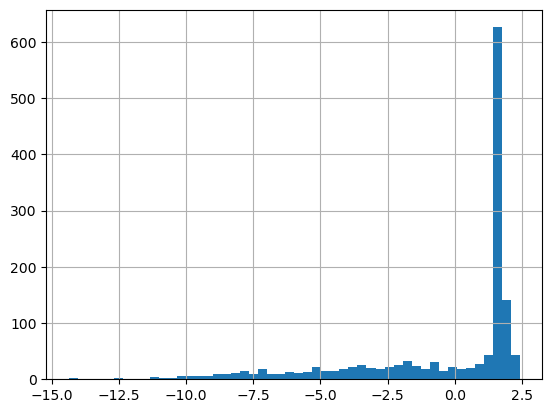

In [41]:
for scheme in dem_mgmt_schemes:
    travs_df[scheme]['gtt_diff'] = travs_df[scheme]['gtt'] - travs_df[unhindered_travel_scn]['gtt']
    travs_df[scheme]['cost_diff'] = travs_df[scheme]['cost'] - travs_df[unhindered_travel_scn]['cost']
    travs_df[scheme]['constant_diff'] = travs_df[scheme]['constant'] - travs_df[unhindered_travel_scn]['constant']
    travs_df[scheme]['trading_costs_diff'] = travs_df[scheme]['money_spent_buying_credits'] - travs_df[unhindered_travel_scn]['money_spent_buying_credits']
    travs_df[scheme]['welfare_diff_gtt'] = travs_df[scheme]['gtt_diff'] / 3600 * -travs_df[scheme]['VoT']
    travs_df[scheme]['welfare_diff_constant'] = travs_df[scheme]['constant_diff'] / (-params[scheme]['evol']['travellers']['mode_pref']['beta_cost'])
    travs_df[scheme]['welfare_diff_cost'] = -travs_df[scheme]['cost_diff']
    travs_df[scheme]['welfare_diff_trading_costs'] = -travs_df[scheme]['trading_costs_diff']
    travs_df[scheme]['welfare_diff'] = travs_df[scheme]['welfare_diff_gtt'] + travs_df[scheme]['welfare_diff_constant'] + travs_df[scheme]['welfare_diff_cost'] + travs_df[scheme]['welfare_diff_trading_costs']

travs_df['tmc10']['welfare_diff'].hist(bins=50)

In [42]:
for scheme in dem_mgmt_schemes:
    travs_df[scheme]['pt_car_tt_multiplier'] = (travs_df[scheme]['PT_ivTime'] + travs_df[scheme]['PT_waitingTime']) / travs_df[scheme]['ttrav_car']

In [43]:
# Groupby postcode and calculate mean welfare difference
welfare_diff_by_postcode = travs_df['tmc10'].groupby('zone_id')['welfare_diff'].mean().reset_index()
welfare_diff_by_bike_option = travs_df['tmc10'].groupby('bike_option')['welfare_diff'].mean().reset_index()

In [44]:
travs_df['tmc10'].groupby('car_option')['welfare_diff'].mean().reset_index()

,car_option,welfare_diff
0,False,0.635362
1,True,-1.331422


In [45]:
welfare_diff_by_bike_option

,bike_option,welfare_diff
0,False,-4.162100
1,True,-0.443932


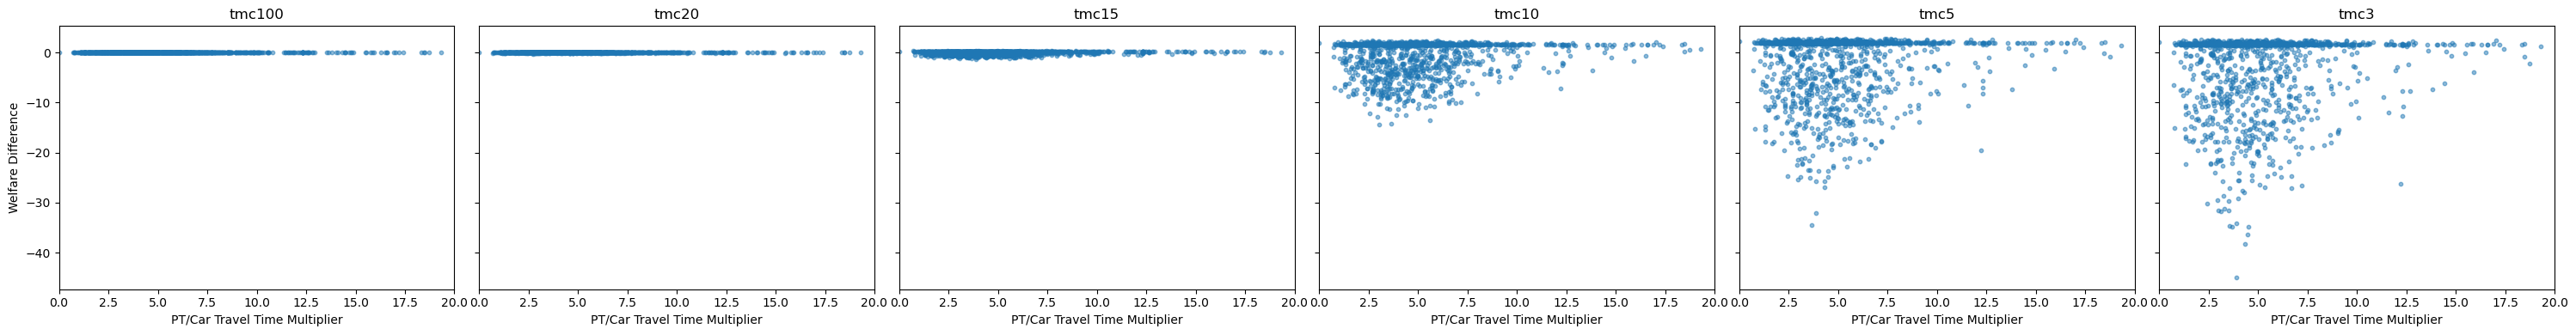

In [46]:
n_schemes = len(dem_mgmt_schemes)
fig, axes = plt.subplots(nrows=1, ncols=n_schemes, figsize=(5 * n_schemes, 4), sharey=True)

if n_schemes == 1:
    axes = [axes]  # Ensure axes is iterable

for i, scheme in enumerate(dem_mgmt_schemes):
    if 'pt_car_tt_multiplier' in travs_df[scheme].columns and 'welfare_diff' in travs_df[scheme].columns:
        axes[i].scatter(
            travs_df[scheme]['pt_car_tt_multiplier'],
            travs_df[scheme]['welfare_diff'],
            alpha=0.5,
            s=10
        )
        axes[i].set_xlim(0, 20)
        axes[i].set_xlabel('PT/Car Travel Time Multiplier')
        axes[i].set_title(scheme)
axes[0].set_ylabel('Welfare Difference')
plt.tight_layout()
plt.show()

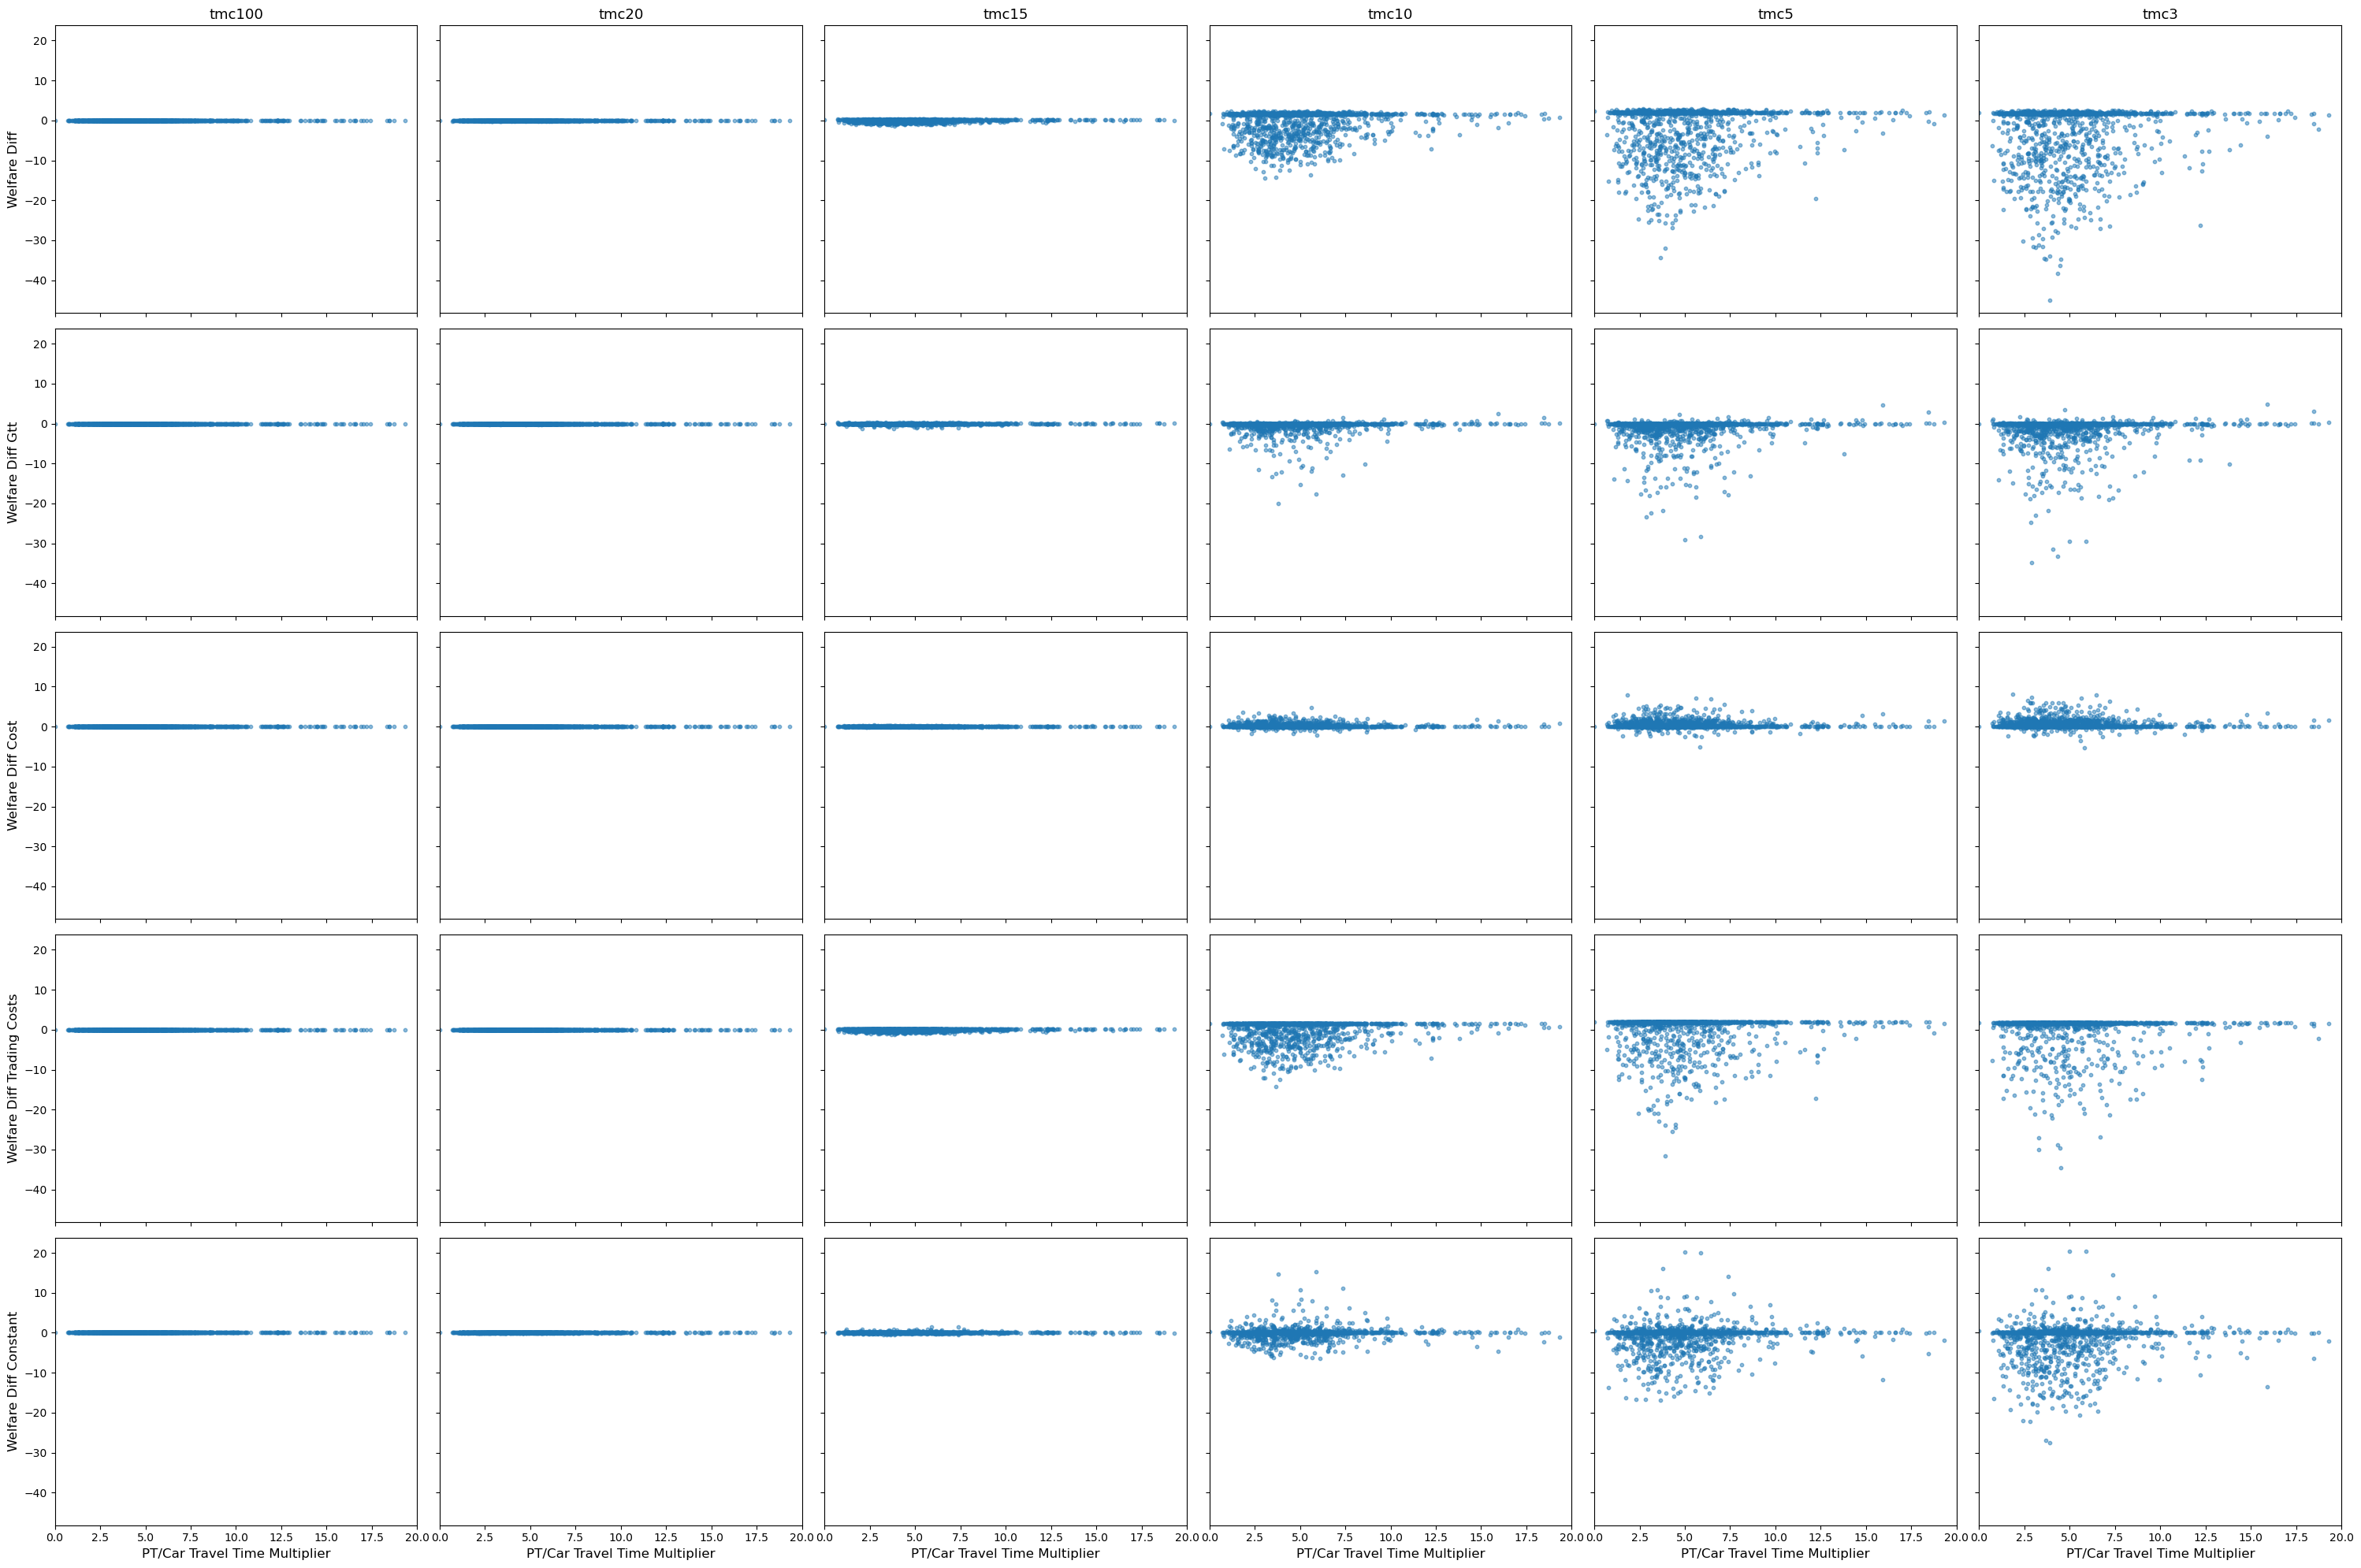

In [49]:
indicators = ['welfare_diff', 'welfare_diff_gtt', 'welfare_diff_cost', 'welfare_diff_trading_costs', 'welfare_diff_constant']
n_schemes = len(dem_mgmt_schemes)
n_indicators = len(indicators)

fig, axes = plt.subplots(nrows=n_indicators, ncols=n_schemes, figsize=(5 * n_schemes, 4 * n_indicators), sharex=True, sharey=True)

if n_schemes == 1:
    axes = np.expand_dims(axes, axis=1)  # Ensure axes is 2D

for col, scheme in enumerate(dem_mgmt_schemes):
    for row, indicator in enumerate(indicators):
        ax = axes[row, col]
        if ('pt_car_tt_multiplier' in travs_df[scheme].columns and
            indicator in travs_df[scheme].columns):
            ax.scatter(
                travs_df[scheme]['pt_car_tt_multiplier'],
                travs_df[scheme][indicator],
                alpha=0.5,
                s=10
            )
        ax.set_xlim(0, 20)
        if col == 0:
            ax.set_ylabel(indicator.replace('_', ' ').title(), fontsize=12)
        if row == n_indicators - 1:
            ax.set_xlabel('PT/Car Travel Time Multiplier', fontsize=12)
        if row == 0:
            ax.set_title(scheme, fontsize=13)

plt.tight_layout()
plt.show()

In [40]:
travs_df['tmc10']['constant_diff'].max()

np.float64(5.81170098968421)

In [ ]:
-params['tmc10']['evol']['travellers']['mode_pref']['beta_cost']

0.381